# Machine Learning-Based Diabetes Early Detection System


### Import libraries

Standard data-handling, visualisation and machine-learning libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

import joblib  # for saving the trained model to disk

# Visualisation (used for quick data-quality checks)
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models (the 3 options compared in the proposal)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix)

# Model export
import joblib

# Fixed seed so results are reproducible (NFR3 - Reliability)
RANDOM_STATE = 42

# Show plots inline
%matplotlib inline
sns.set_style("whitegrid")

## Dataset Preparation

This phase covers the Gantt chart tasks dataset inspection, feature engineering & preparation, data cleaning, missing-value / data-quality analysis, and feature preparation.

### Load the dataset and inspect its structure

We load the Excel file provided for the project and check its shape, column types, and the first few rows to confirm it matches the 20,000-instance / 15-feature description from the proposal.

In [2]:
# Import core libraries for data handling
import pandas as pd  # data loading and manipulation
import numpy as np   # numerical operations

# Load the diabetes dataset provided for the project
df = pd.read_excel("Diabetes Dataset.xlsx")  # read the Excel file into a DataFrame

# Confirm the dataset size matches the proposal (20,000 instances, 15 features)
print("Shape (rows, columns):", df.shape)

# Preview the first 5 rows to inspect the raw structure
df.head()

Shape (rows, columns): (20000, 15)


,Gender,Age,Physical Activity,Smoking Status,Alcohol Intake,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI,Cholesterol,Diabetes Pedigree Function,Family History,Hypertension,Outcome
0,Male,63,Moderate,Former,NaN,103,40,7,41,28.196216,167,1.393,Yes,Yes,Diabetic
1,Female,51,Moderate,Never,Regular,104,59,21,51,30.438114,209,0.815,No,No,Diabetic
2,Female,74,Moderate,Current,NaN,128,70,18,199,38.700428,170,0.244,No,No,Diabetic
3,Male,78,Low,Never,Occasional,148,72,15,110,44.861600,170,0.336,No,No,Diabetic
4,Male,32,High,Never,NaN,102,55,18,49,21.591572,211,1.146,Yes,No,Non-diabetic


### Data-quality and missing-value analysis

We check column data types and count missing values per column. This corresponds directly to the "Missing-value and data-quality analysis" task and the data-quality risk identified in the Risk Management Plan

In [3]:
# Check data types of every column (numeric vs categorical)
print(df.dtypes)
print()

# Count missing (null) values per column to identify data-quality issues
missing_counts = df.isnull().sum()
print("Missing values per column:")
print(missing_counts[missing_counts > 0])  # only show columns that actually have missing data

# Check class balance of the target variable (Outcome)
print()
print("Outcome class balance:")
print(df["Outcome"].value_counts())

Gender                         object
Age                             int64
Physical Activity              object
Smoking Status                 object
Alcohol Intake                 object
Glucose                         int64
Blood Pressure                  int64
Skin Thickness                  int64
Insulin                         int64
BMI                           float64
Cholesterol                     int64
Diabetes Pedigree Function    float64
Family History                 object
Hypertension                   object
Outcome                        object
dtype: object

Missing values per column:
Alcohol Intake    9925
dtype: int64

Outcome class balance:
Outcome
Diabetic        16726
Non-diabetic     3274
Name: count, dtype: int64


**Observation:** the `Alcohol Intake` column has a large number of missing values, and the target variable `Outcome` is **imbalanced** (far more `Diabetic` than `Non-diabetic` records). Both issues are handled explicitly below: missing values are treated as their own category, and the train/test split is stratified so the imbalance is preserved consistently in both sets (addressing the "Poor data quality" risk from the proposal's Risk Register).

### Data cleaning

Missing values in `Alcohol Intake` most plausibly represent patients who reported no alcohol consumption at all, rather than a data-entry error, since the only other categories are `Regular` and `Occasional`. We therefore fill missing values with an explicit `"None"` category instead of dropping rows, to avoid unnecessarily discarding patient records.

In [4]:
# Fill missing Alcohol Intake values with an explicit "None" category
# (rather than dropping rows, which would waste usable patient data)
df["Alcohol Intake"] = df["Alcohol Intake"].fillna("None")

# Re-check that there are no missing values left in the dataset
print("Remaining missing values:", df.isnull().sum().sum())

# Drop exact duplicate rows, if any, as a further cleaning step
duplicates_removed = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Duplicate rows removed: {duplicates_removed}")
print("Shape after cleaning:", df.shape)

Remaining missing values: 0
Duplicate rows removed: 0
Shape after cleaning: (20000, 15)


### Feature preparation and encoding

Machine-learning algorithms require numeric input, so categorical columns (`Gender`, `Physical Activity`, `Smoking Status`, `Alcohol Intake`, `Family History`, `Hypertension`) are encoded, and the target `Outcome` is mapped to a binary 0/1 label (`Diabetic` = 1, `Non-diabetic` = 0) for classification.

In [5]:
# Separate the target variable from the predictor features
target_col = "Outcome"

# Encode the target: Diabetic = 1, Non-diabetic = 0
y = df[target_col].map({"Diabetic": 1, "Non-diabetic": 0})

# Identify categorical (text) columns that need encoding
categorical_cols = df.drop(columns=[target_col]).select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# One-hot encode categorical columns (drop_first=True avoids redundant dummy columns)
X = pd.get_dummies(df.drop(columns=[target_col]), columns=categorical_cols, drop_first=True)

print("Final feature matrix shape:", X.shape)
X.head()

Categorical columns to encode: ['Gender', 'Physical Activity', 'Smoking Status', 'Alcohol Intake', 'Family History', 'Hypertension']
Final feature matrix shape: (20000, 17)


,Age,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI,Cholesterol,Diabetes Pedigree Function,Gender_Male,Physical Activity_Low,Physical Activity_Moderate,Smoking Status_Former,Smoking Status_Never,Alcohol Intake_Occasional,Alcohol Intake_Regular,Family History_Yes,Hypertension_Yes
0,63,103,40,7,41,28.196216,167,1.393,True,False,True,True,False,False,False,True,True
1,51,104,59,21,51,30.438114,209,0.815,False,False,True,False,True,False,True,False,False
2,74,128,70,18,199,38.700428,170,0.244,False,False,True,False,False,False,False,False,False
3,78,148,72,15,110,44.861600,170,0.336,True,True,False,False,True,True,False,False,False
4,32,102,55,18,49,21.591572,211,1.146,True,False,False,False,True,False,False,True,False


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure, quality, distribution, and relationships within the diabetes dataset. The analysis examines missing values, duplicate records, target-class balance, numerical and categorical feature distributions, potential outliers, correlations, and relationships between important features and diabetes outcomes. These findings support informed preprocessing and model development decisions.

### Dataset Overview

This section examines the size, structure, data types, and basic statistical characteristics of the dataset. Understanding these properties helps identify the types of variables available and potential data-quality issues before preprocessing.

In [6]:
# Display dataset dimensions
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

# Display statistical summary
print("\nStatistical Summary:")
display(df.describe(include="all").T)

Dataset Shape: (20000, 15)

Column Names:
['Gender', 'Age', 'Physical Activity', 'Smoking Status', 'Alcohol Intake', 'Glucose', 'Blood Pressure', 'Skin Thickness', 'Insulin', 'BMI', 'Cholesterol', 'Diabetes Pedigree Function', 'Family History', 'Hypertension', 'Outcome']

Data Types:


,Data Type
Gender,object
Age,int64
Physical Activity,object
Smoking Status,object
Alcohol Intake,object
Glucose,int64
Blood Pressure,int64
Skin Thickness,int64
Insulin,int64
BMI,float64



Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,20000,2,Male,10028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,20000.0,NaN,NaN,NaN,49.5654,17.320956,20.0,35.0,50.0,64.0,79.0
Physical Activity,20000,3,Moderate,9976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smoking Status,20000,3,Never,11999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alcohol Intake,20000,3,None,9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Glucose,20000.0,NaN,NaN,NaN,119.6034,29.590699,40.0,99.0,120.0,140.0,200.0
Blood Pressure,20000.0,NaN,NaN,NaN,69.43285,12.016115,30.0,61.0,69.0,78.0,114.0
Skin Thickness,20000.0,NaN,NaN,NaN,20.10545,9.130969,7.0,13.0,20.0,26.0,57.0
Insulin,20000.0,NaN,NaN,NaN,83.95255,53.026841,15.0,40.0,79.0,120.0,276.0
BMI,20000.0,NaN,NaN,NaN,32.00898,6.913271,15.0,27.314424,31.99404,36.750196,50.0


### Missing Value Analysis

Missing-value analysis is performed to identify incomplete observations and determine which variables require attention during preprocessing. The number and percentage of missing values are calculated for each feature.

In [7]:
# Calculate missing values
missing_count = df.isnull().sum()

# Calculate missing-value percentage
missing_percentage = (missing_count / len(df)) * 100

# Create summary table
missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage
})

print("Missing Value Analysis:")
display(missing_summary)

# Select only features that contain missing values
missing_features = missing_percentage[missing_percentage > 0].sort_values(
    ascending=False
)

# Visualise missing values only when missing values exist
if len(missing_features) > 0:
    plt.figure(figsize=(10, 5))

    missing_features.plot(kind="bar")

    plt.title("Missing Values by Feature")
    plt.xlabel("Feature")
    plt.ylabel("Missing Percentage (%)")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:
    print("\nNo missing values were found in the dataset.")

Missing Value Analysis:


,Missing Values,Missing Percentage
Gender,0,0.0
Age,0,0.0
Physical Activity,0,0.0
Smoking Status,0,0.0
Alcohol Intake,0,0.0
Glucose,0,0.0
Blood Pressure,0,0.0
Skin Thickness,0,0.0
Insulin,0,0.0
BMI,0,0.0



No missing values were found in the dataset.


### Duplicate Record Analysis

Duplicate records can introduce bias into model training if the same observation appears multiple times. The dataset is therefore examined to determine the number of duplicated rows.

In [8]:
# Count duplicate records
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)
print("Percentage of duplicate records:",
      round((duplicate_count / len(df)) * 100, 2), "%")

Number of duplicate records: 0
Percentage of duplicate records: 0.0 %


### Target Variable Distribution

The target variable represents the diabetes outcome. Its class distribution is examined to determine whether the dataset is balanced or imbalanced. Class imbalance can affect classification performance and is therefore considered when interpreting model evaluation results.

Target Class Counts:


Outcome
Diabetic        16726
Non-diabetic     3274
Name: count, dtype: int64


Target Class Percentages:


Outcome
Diabetic        83.63
Non-diabetic    16.37
Name: proportion, dtype: float64

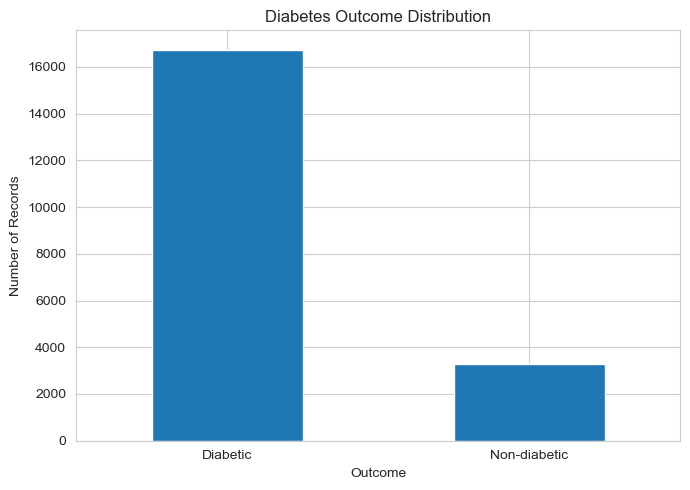

In [9]:
# Display target distribution
target_counts = df["Outcome"].value_counts()

print("Target Class Counts:")
display(target_counts)

# Calculate percentages
target_percentage = df["Outcome"].value_counts(normalize=True) * 100

print("\nTarget Class Percentages:")
display(target_percentage.round(2))

plt.figure(figsize=(7, 5))

df["Outcome"].value_counts().plot(kind="bar")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Numerical Feature Distribution

Histograms are used to examine the distribution of numerical variables. This helps identify skewness, concentration of observations, unusual ranges, and potential data-quality issues.

Numerical Features:
['Age', 'Glucose', 'Blood Pressure', 'Skin Thickness', 'Insulin', 'BMI', 'Cholesterol', 'Diabetes Pedigree Function']


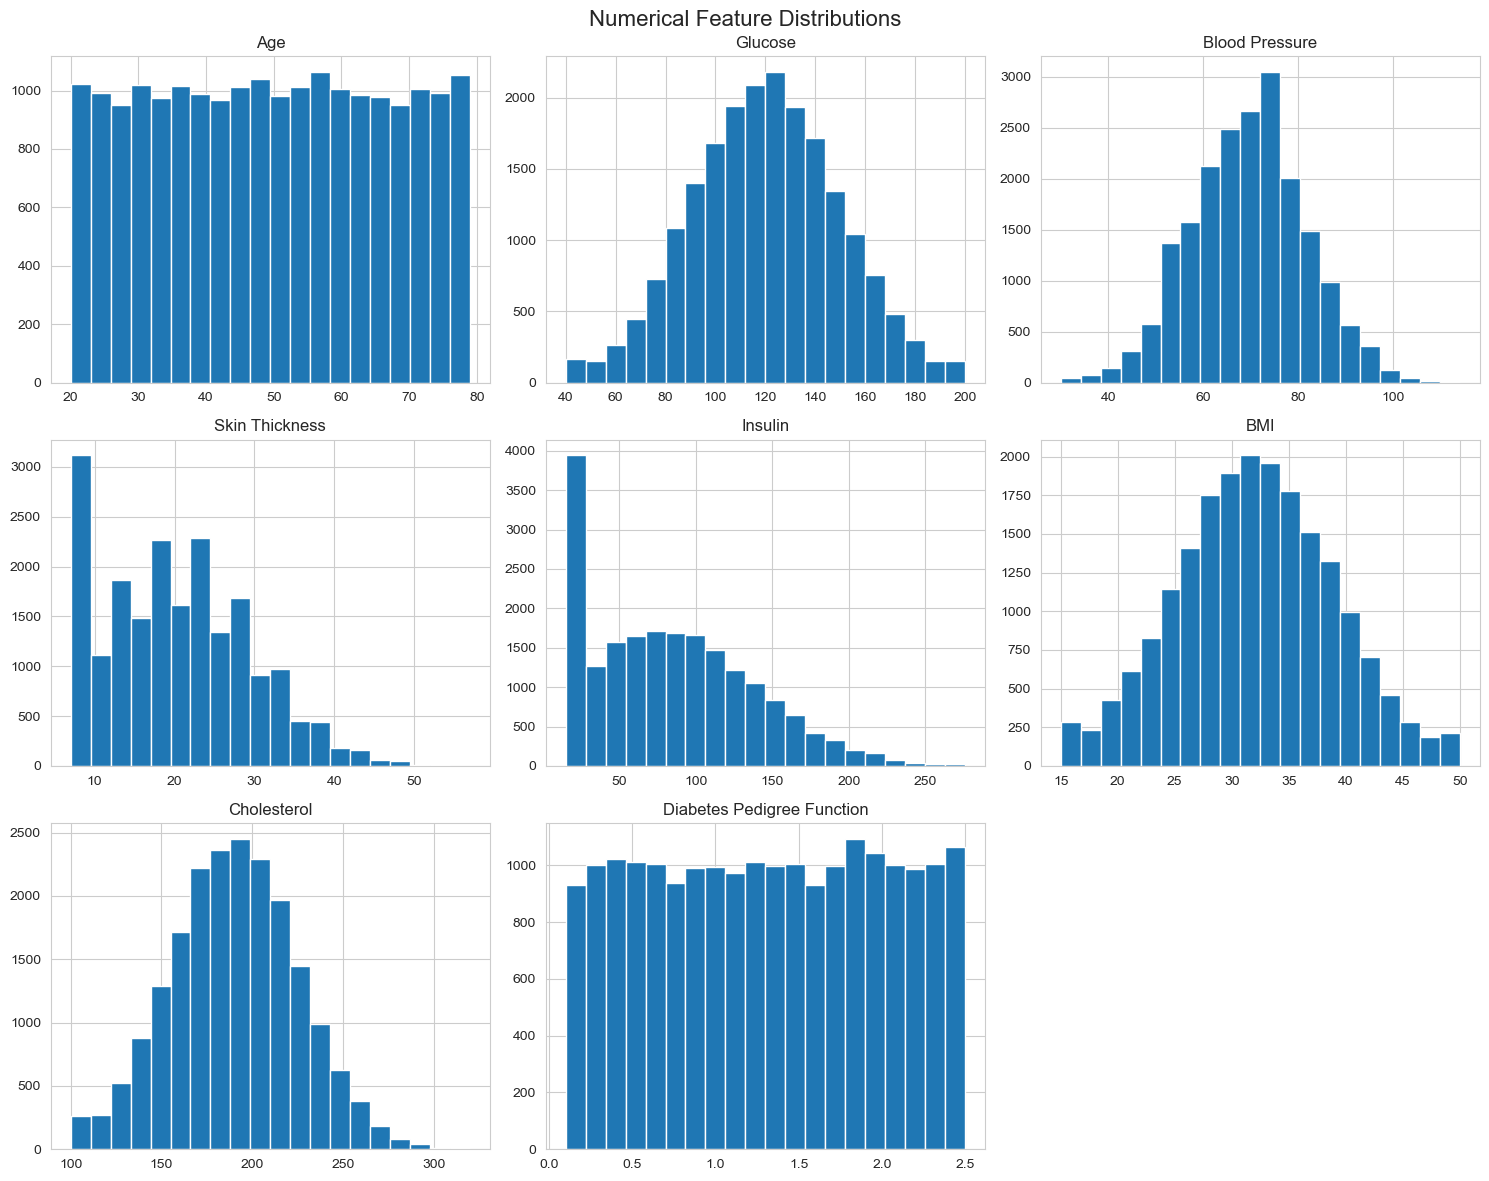

In [10]:
# Identify numerical columns
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical Features:")
print(numerical_columns.tolist())

# Plot distributions
df[numerical_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle("Numerical Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

### Categorical Feature Distribution

Categorical variables are examined to understand the frequency of their individual categories. This analysis helps identify dominant categories, rare categories, and potential inconsistencies before encoding.

Categorical Features:
['Gender', 'Physical Activity', 'Smoking Status', 'Alcohol Intake', 'Family History', 'Hypertension', 'Outcome']

Gender


Gender
Male      10028
Female     9972
Name: count, dtype: int64


Physical Activity


Physical Activity
Moderate    9976
Low         5995
High        4029
Name: count, dtype: int64


Smoking Status


...

Family History
No     12083
Yes     7917
Name: count, dtype: int64


Hypertension


Hypertension
No     13974
Yes     6026
Name: count, dtype: int64


Outcome


Outcome
Diabetic        16726
Non-diabetic     3274
Name: count, dtype: int64

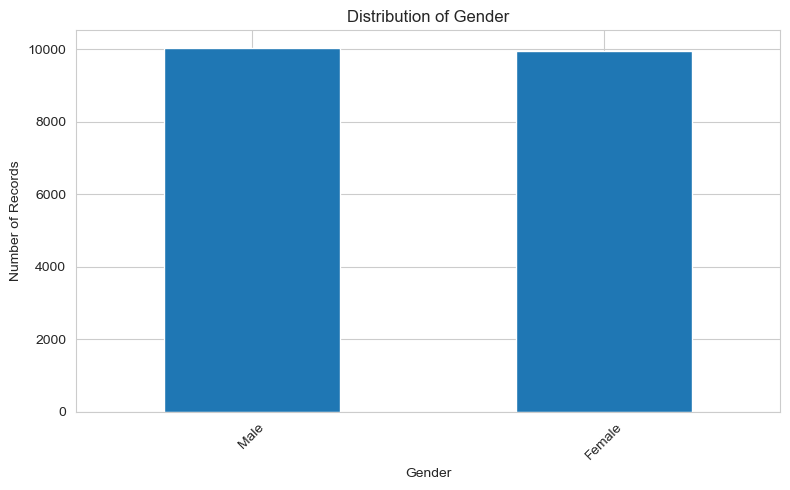

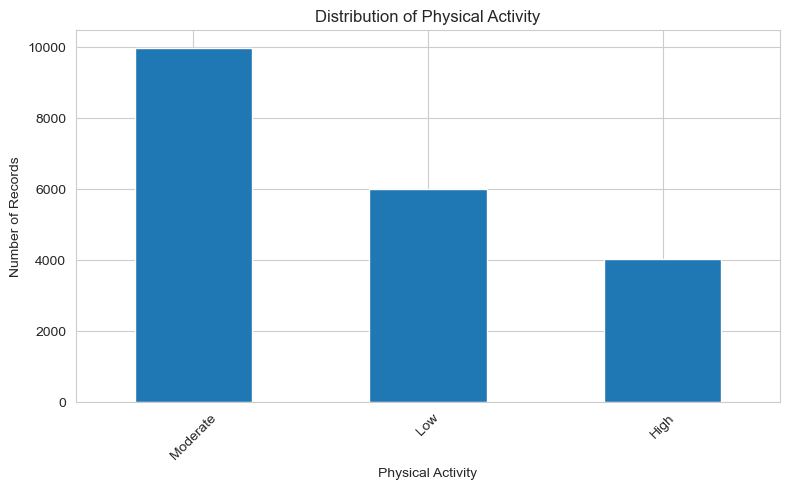

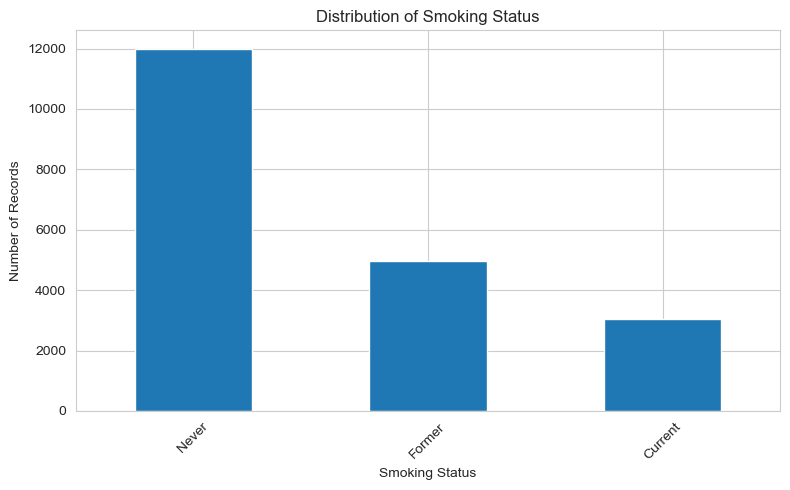

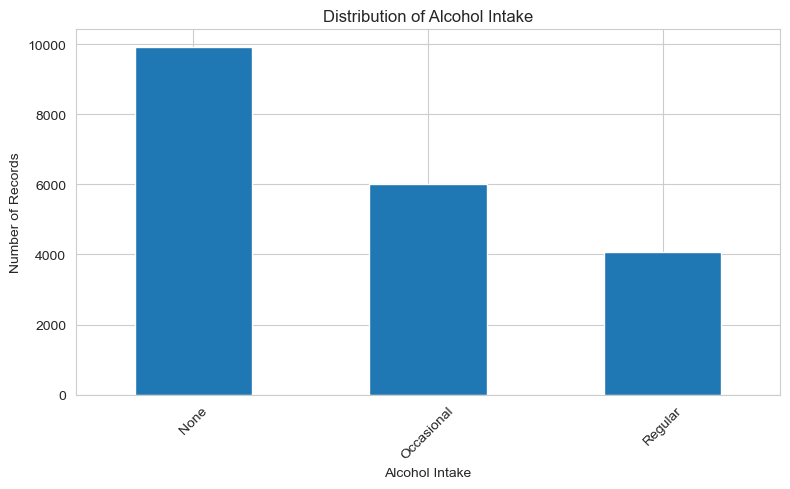

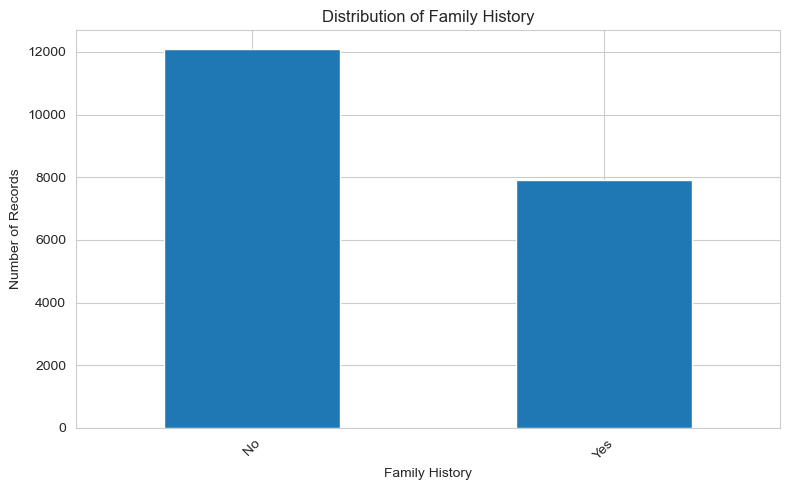

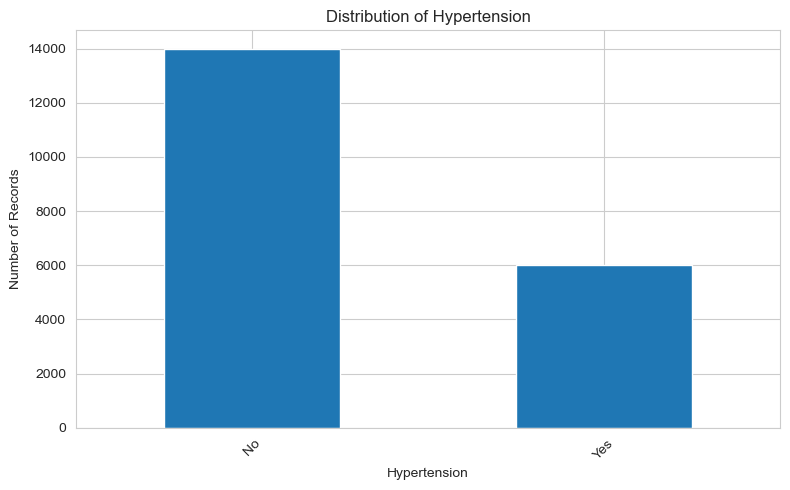

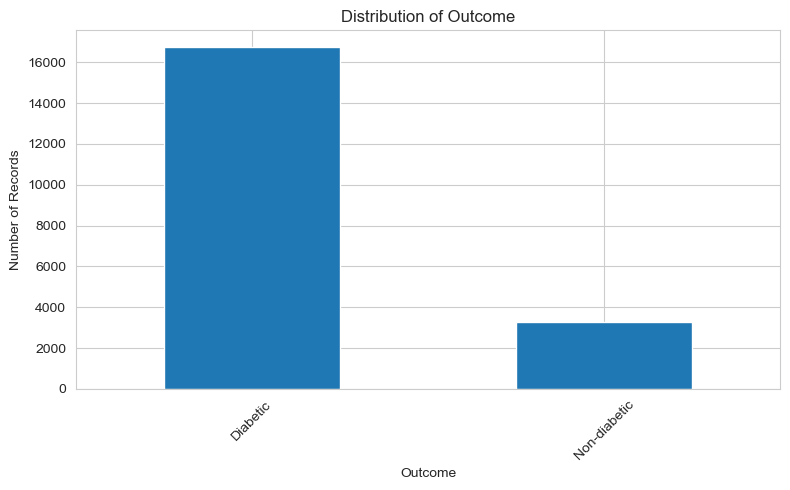

In [11]:
# Identify categorical columns
categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("Categorical Features:")
print(categorical_columns.tolist())

# Display category frequencies
for column in categorical_columns:
    print(f"\n{column}")
    display(df[column].value_counts(dropna=False))

# Plot categorical feature distributions
for column in categorical_columns:

    plt.figure(figsize=(8, 5))

    df[column].value_counts(dropna=False).plot(kind="bar")

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

### Correlation Analysis

Correlation analysis is performed to examine relationships between numerical variables. The correlation matrix helps identify strongly related features and provides an initial understanding of relationships that may be relevant to diabetes prediction.

,Age,Glucose,Blood Pressure,Skin Thickness,Insulin,BMI,Cholesterol,Diabetes Pedigree Function
Age,1.000000,-0.007980,0.007771,0.002991,0.002514,0.009207,-0.001041,0.002134
Glucose,-0.007980,1.000000,0.012727,-0.006041,-0.002759,0.001784,0.014739,-0.003629
Blood Pressure,0.007771,0.012727,1.000000,-0.000314,0.009195,-0.003029,-0.005123,0.003640
Skin Thickness,0.002991,-0.006041,-0.000314,1.000000,0.007328,-0.006512,0.003944,0.001038
Insulin,0.002514,-0.002759,0.009195,0.007328,1.000000,0.000912,0.006441,-0.010823
BMI,0.009207,0.001784,-0.003029,-0.006512,0.000912,1.000000,-0.005973,-0.004165
Cholesterol,-0.001041,0.014739,-0.005123,0.003944,0.006441,-0.005973,1.000000,-0.006669
Diabetes Pedigree Function,0.002134,-0.003629,0.003640,0.001038,-0.010823,-0.004165,-0.006669,1.000000


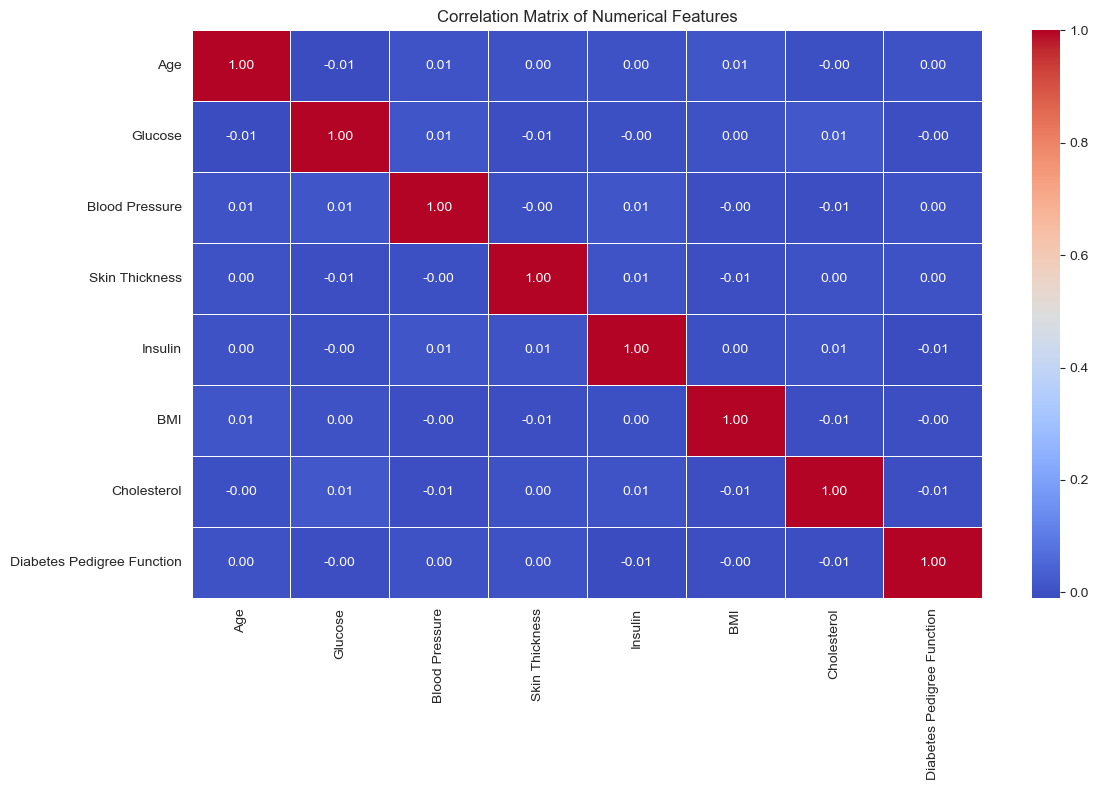

In [12]:
# Calculate correlation matrix
correlation_matrix = df[numerical_columns].corr()

# Display correlation matrix
display(correlation_matrix)

# Visualise correlations
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Feature Relationships with Diabetes Outcome

Important numerical features are compared across diabetes outcome classes to identify differences in their distributions. Boxplots provide a visual comparison between patients with and without diabetes.

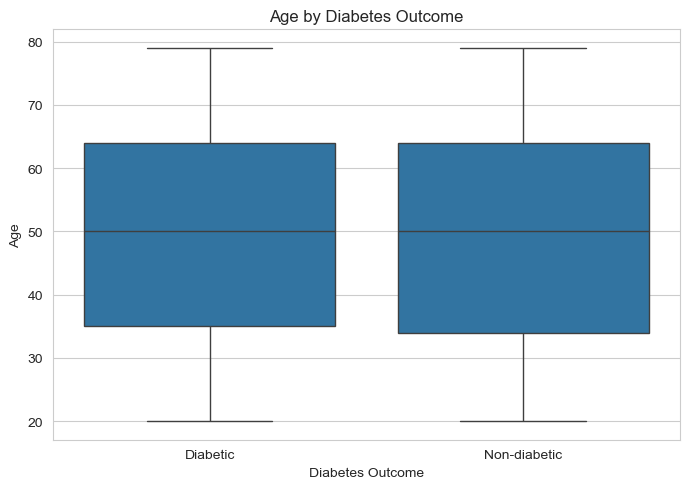

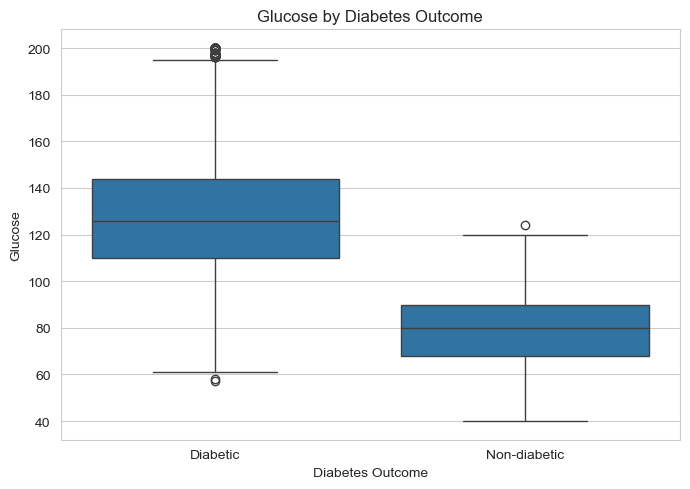

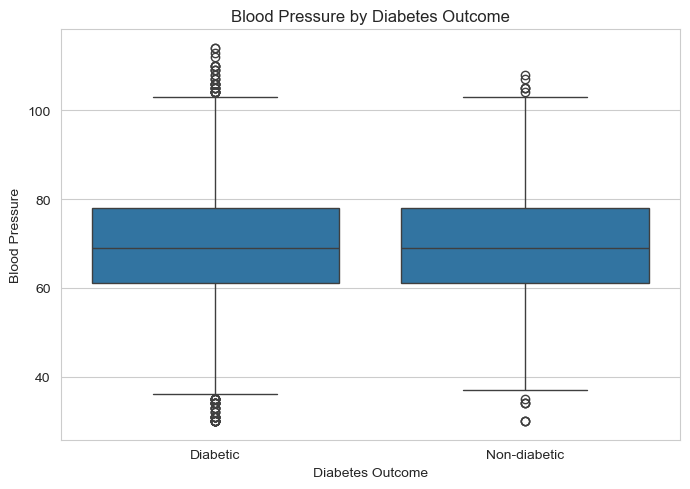

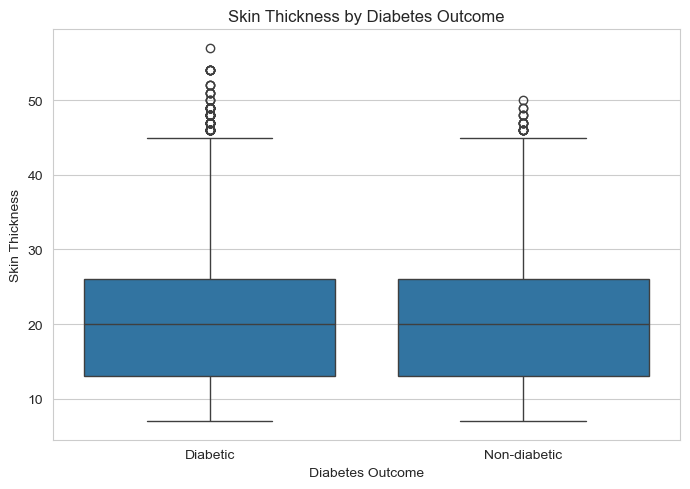

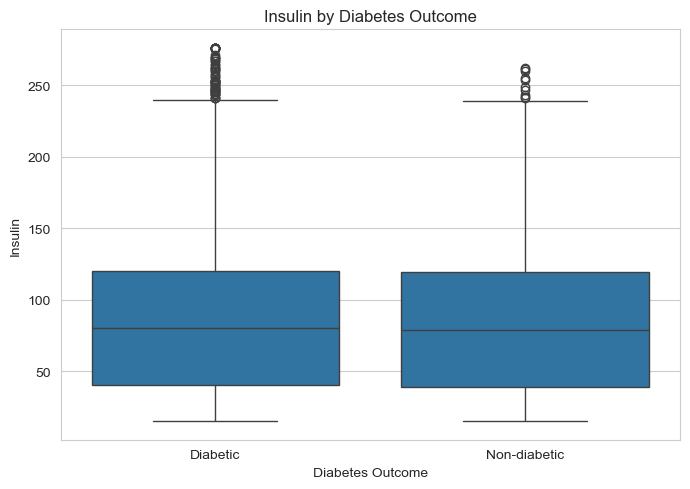

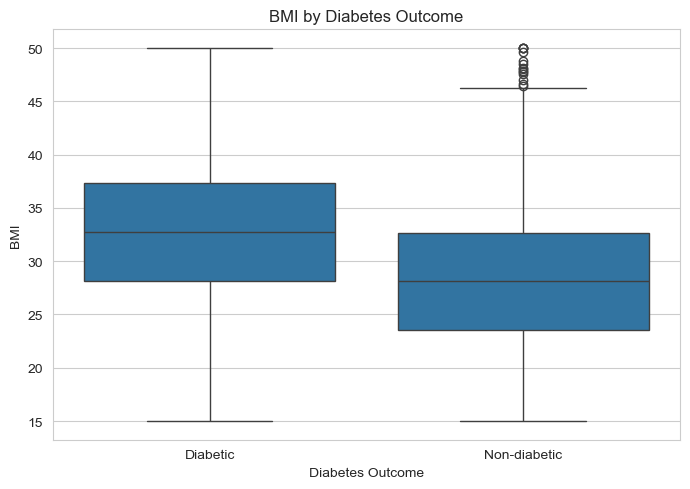

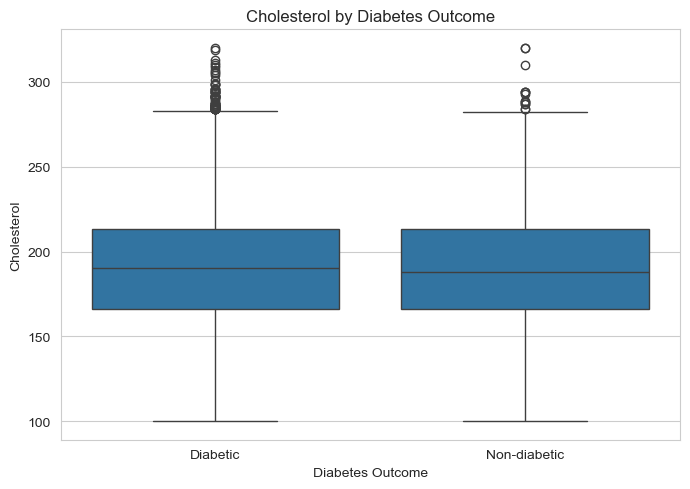

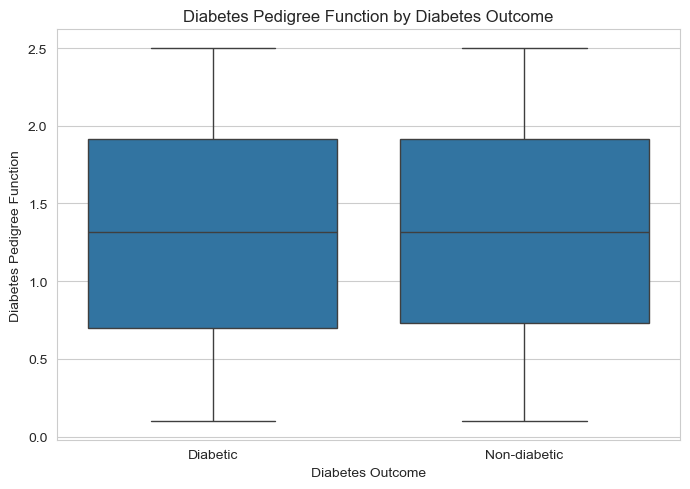

In [13]:
# Select numerical features excluding the target
feature_columns = [
    column for column in numerical_columns
    if column != "Outcome"
]

# Create boxplots against the target
for column in feature_columns:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="Outcome",
        y=column
    )

    plt.title(f"{column} by Diabetes Outcome")
    plt.xlabel("Diabetes Outcome")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

### Train/test split and feature scaling

The data is split into training (80%) and test (20%) sets using **stratified sampling** on `Outcome`, so the class imbalance noted above is preserved in both sets (supports NFR3 — Reliability, consistent evaluation). Features are then standardised, which benefits distance-based/gradient-based models such as SVM and Logistic Regression.

In [14]:
from sklearn.model_selection import train_test_split  # for splitting data
from sklearn.preprocessing import StandardScaler          # for feature scaling

# Split into train/test sets, stratifying on Outcome to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% held out for testing
    random_state=42,     # fixed seed for reproducibility (NFR3 - Reliability)
    stratify=y           # preserve the Diabetic / Non-diabetic ratio in both sets
)

# Standardise features (mean=0, std=1) - fit on train, apply to both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit scaler only on training data
X_test_scaled = scaler.transform(X_test)        # apply same scaling to test data

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

Training set size: (16000, 17)
Test set size: (4000, 17)


## Machine Learning Model Development

As specified in the proposal, four candidate classifiers are trained and compared: **Logistic Regression, Random Forest, Support Vector Machine, and XGBoost.** Each is evaluated using Accuracy, Precision, Recall, F1-score and ROC-AUC, matching the Evaluation Plan.

### Train the four candidate models

Each model is trained on the scaled training data with reasonable default/tuned hyperparameters. `class_weight="balanced"` is used where supported, to account for the class imbalance identified during data-quality analysis.

In [15]:
# Dictionary of candidate models, as proposed in Assessment 1 Section 7 & Introduction
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42
    ),
    "Support Vector Machine": SVC(
        kernel="rbf", class_weight="balanced", probability=True, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, learning_rate=0.1, eval_metric="logloss", random_state=42
    ),
}

# Train (fit) every model on the scaled training data
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained.")

Logistic Regression trained.
Random Forest trained.
Support Vector Machine trained.
XGBoost trained.


Support Vector Machine trained.


XGBoost trained.


### Compare all four models

Each trained model predicts on the held-out test set. We compute Accuracy, Precision, Recall, F1-score and ROC-AUC for every model and collect the results into a single comparison table, as required by the Evaluation Plan.

In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

results = []  # will hold one row of metrics per model

# Evaluate every trained model on the test set
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)                    # class predictions
    y_proba = model.predict_proba(X_test_scaled)[:, 1]        # probability of class 1 (Diabetic)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

# Build a comparison table sorted by F1 Score (balances precision & recall for imbalanced data)
comparison_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.97625,0.984496,0.987145,0.985819,0.996594
1,Random Forest,0.97425,0.983015,0.986248,0.984629,0.996462
2,Logistic Regression,0.96750,0.996295,0.964723,0.980255,0.997122
3,Support Vector Machine,0.96075,0.996264,0.956652,0.976056,0.996074


### Model validation

For additional validation, we inspect the confusion matrix of the top-ranked model to check how it performs specifically on the minority class (`Non-diabetic`), which the Ethical Considerations section flags as important — a poor result here would risk incorrect reassurance for patients.

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

# Identify the best model by F1 Score from the comparison table
best_model_name = comparison_df.iloc[0]["Model"]
best_model = models[best_model_name]

# Generate predictions from the best model for validation
y_pred_best = best_model.predict(X_test_scaled)

print(f"Validation report for best model: {best_model_name}\n")
print("Confusion matrix (rows=actual, columns=predicted):")
print(confusion_matrix(y_test, y_pred_best))
print()
print(classification_report(y_test, y_pred_best, target_names=["Non-diabetic", "Diabetic"]))

Validation report for best model: XGBoost

Confusion matrix (rows=actual, columns=predicted):
[[ 603   52]
 [  43 3302]]

              precision    recall  f1-score   support

Non-diabetic       0.93      0.92      0.93       655
    Diabetic       0.98      0.99      0.99      3345

    accuracy                           0.98      4000
   macro avg       0.96      0.95      0.96      4000
weighted avg       0.98      0.98      0.98      4000



### Final comparison and export of the best model

The comparison table below is the final output of the model-selection process. The best-performing model (highest F1 Score) is saved to disk with `joblib`, together with the fitted `StandardScaler` and the one-hot-encoded feature column list, so it can later be loaded by the web interface for real-time predictions.

In [18]:
import joblib  # for saving the trained model to disk

# Display the final ranked comparison table
print("Final model comparison (ranked by F1 Score):")
display(comparison_df)

print(f"\nBest performing model: {best_model_name}")

# Build a filename from the best model's own name, e.g. "XGBoost_model.pkl"
model_filename = f"{best_model_name.replace(' ', '_')}_model.pkl"

# Save ONLY the best model, named after itself
joblib.dump(best_model, model_filename)

print(f"Saved: {model_filename}")

Final model comparison (ranked by F1 Score):


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.97625,0.984496,0.987145,0.985819,0.996594
1,Random Forest,0.97425,0.983015,0.986248,0.984629,0.996462
2,Logistic Regression,0.96750,0.996295,0.964723,0.980255,0.997122
3,Support Vector Machine,0.96075,0.996264,0.956652,0.976056,0.996074



Best performing model: XGBoost
Saved: XGBoost_model.pkl
